# Modulo 1 - Fondamenti di Machine Learning


ITS Apulia Digital Academy - ML per il Mondo del Lavoro



---


In [1]:
# ----------------------------------------------------------------
# CELLA DI SETUP - eseguire questa cella prima di tutte le altre
# ----------------------------------------------------------------

import numpy as np          # calcolo numerico (array, operazioni matematiche)
import pandas as pd         # tabelle e dataframe
import matplotlib.pyplot as plt  # grafici

# Impostazioni globali dei grafici: dimensione, griglia leggera
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3


---
## Sezione 0 - Statistica Essenziale per ML

La statistica e il linguaggio su cui si basa ogni algoritmo di ML.
Prima di costruire qualsiasi modello, i dati vanno capiti attraverso
le loro proprieta statistiche di base.


### Esercizio S0.1 - Media, Mediana e Varianza

---

**Dati:** stipendi annui (in euro) di 8 persone in una piccola azienda

```
stipendi = [28000, 32000, 34000, 35000, 36000, 38000, 42000, 350000]
```

**Formule da implementare:**

| Misura | Formula | Note |
|--------|---------|------|
| Media  | mu = (1/n) * somma(xi) | sensibile agli outlier |
| Mediana | valore centrale dopo ordinamento | robusta agli outlier |
| Varianza | sigma^2 = (1/n) * somma((xi - mu)^2) | dispersione attorno alla media |
| Deviazione std | sigma = radice(sigma^2) | stessa unita dei dati |

**Cosa fare:**
1. Calcola le quattro misure con NumPy (`np.mean`, `np.median`, `np.var`, `np.std`)
2. Stampa i valori
3. Aggiungi un commento che spiega quale misura e piu rappresentativa e perche

**Concetto chiave:** con un outlier molto grande (il CEO a 350.000 euro),
la media viene trascinata verso l'alto e non e piu rappresentativa.
In ML questo ha conseguenze concrete: se usiamo la media per imputare
i valori mancanti di uno stipendio, inseriamo un valore fuorviante per
la quasi totalita dei dipendenti.

```
         28k  32k  34k  35k  36k  38k  42k          350k
          |    |    |    |    |    |    |              |
-----+----+----+----+----+----+----+----+----...-------+----->
     0                              ^                       stipendio
                                 mediana
                                 35.500
                                                  ^
                                               media
                                              74.375
```


In [5]:
# ----------------------------------------------------------------
# Esercizio S0.1 - Media, Mediana e Varianza
#
# ----------------------------------------------------------------

import numpy as np

stipendi = [28000, 32000, 34000, 35000, 36000, 38000, 42000, 350000]

media = np.mean(stipendi)

mediana = np.median(stipendi)

varianza = np.var(stipendi)

dev = np.std(stipendi)


print(f"{"Media:":<25}{media:>15,.0f} euro")
print(f"{"Mediana:":<25}{mediana:>15,.0f} euro")
print(f"{"Varianza:":<25}{varianza:>15,.0f} euro^2")
print(f"{"Deviazione Standard:":<25}{dev:>15,.0f} euro")




Media:                            74,375 euro
Mediana:                          35,500 euro
Varianza:                 10,867,484,375 euro^2
Deviazione Standard:             104,247 euro


### Esercizio S0.2 - Correlazione tra Variabili

---

**Dati:** ore di studio e voti per 8 studenti

```
ore_studio = [1, 2, 3, 4, 5, 6, 7, 8]
voti       = [18, 20, 22, 24, 25, 27, 29, 30]
```

**Formula - Correlazione di Pearson:**

```
         somma( (xi - x_medio) * (yi - y_medio) )
r = -----------------------------------------------
     radice( somma((xi-x_medio)^2) ) * radice( somma((yi-y_medio)^2) )
```

Il risultato `r` e sempre compreso tra -1 e +1:

```
  r = -1          r = 0           r = +1
  (y)              (y)              (y)
   |  *             |  * *           |          *  *
   | *              | * *  *         |       *  *
   |*               |* * * *         |    *  *
   *                |  * * *         | *  *
  -+------>(x)     -+------>(x)     -+------>(x)
  relazione         nessuna          relazione
  inversa           relazione        diretta
```

**Attenzione:** correlazione non implica causalita.
Esempio classico: gelati venduti e annegamenti crescono insieme (r alto)
perche entrambi dipendono dalla temperatura esterna, non l'uno dall'altro.

**Cosa fare:**
1. Calcola `r` con `np.corrcoef` ed estrai il valore dalla matrice risultante
2. Aggiungi una retta di tendenza con `np.polyfit` (grado 1)
3. Traccia scatter plot con la retta di tendenza
4. Aggiungi un commento sull'interpretazione di `r`


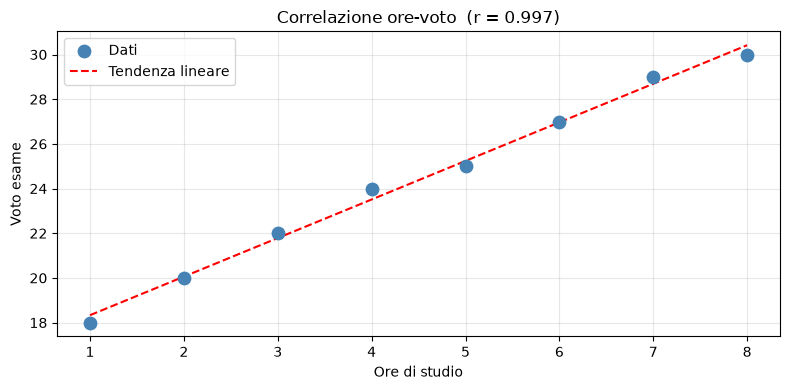

r = 0.9971
Correlazione positiva quasi perfetta: studiare di piu tende a far alzare il voto.


In [6]:
# ----------------------------------------------------------------
# Esercizio S0.3 - Correlazione tra Variabili
#
# ----------------------------------------------------------------

ore_studio = np.array([1, 2, 3, 4, 5, 6, 7, 8])
voti       = np.array([18, 20, 22, 24, 25, 27, 29, 30])

matrice = np.corrcoef(ore_studio, voti)
r = matrice[0, 1]

m, q = np.polyfit(ore_studio, voti, deg=1)

plt.figure()
plt.scatter(ore_studio, voti, color="steelblue", s=80, zorder=5, label="Dati")
plt.plot(ore_studio, m * ore_studio + q,
         color="red", linestyle="--", label="Tendenza lineare")
plt.xlabel("Ore di studio")
plt.ylabel("Voto esame")
plt.title("Correlazione ore-voto  (r = {:.3f})".format(r))
plt.legend()
plt.tight_layout()
plt.show()

print("r = {:.4f}".format(r))
print("Correlazione positiva quasi perfetta: studiare di piu tende a far alzare il voto.")

### Esercizio S0.3 - Probabilita Condizionata

**Riferimento: Sezione 0 - Probabilita condizionata**

---

**Definizione:**

```
    P(A | B) = P(A e B) / P(B)          con P(B) > 0

    Si legge: "probabilita di A dato B"
    Ci si restringe ai soli casi in cui B e vero,
    e si chiede in quanti di quei casi e vero anche A.
```

**Scenario:** test diagnostico su 100 persone per una malattia

**Tabella di contingenza (dati osservati):**

| | Test Positivo | Test Negativo | Totale |
|---|---|---|---|
| **Malato** | 9 | 1 | 10 |
| **Sano** | 9 | 81 | 90 |
| **Totale** | 18 | 82 | 100 |

**Cosa fare:**
1. Calcola `P(Malato)`: quota di persone malate sul totale
2. Calcola `P(Positivo | Malato)`: tra i malati, quanti risultano positivi al test
3. Calcola `P(Positivo | Sano)`: tra i sani, quanti risultano positivi al test
4. Verifica numericamente l'uguaglianza `P(A|B) * P(B) = P(A e B)`

**Concetto chiave:** qui calcoliamo la probabilita nella direzione "naturale"
(dato che una persona e malata, qual e la probabilita che il test sia positivo).
Il problema opposto - dato un test positivo, qual e la probabilita di essere
davvero malati - richiede uno strumento diverso (il Teorema di Bayes), che
vedremo formalizzato e applicato alla classificazione nell'Unita 3.4 del corso.


In [ ]:
# ----------------------------------------------------------------
# Esercizio S0.4 - Probabilita Condizionata
# Riferimento: Sezione 0 - Probabilita condizionata
# ----------------------------------------------------------------

malati_positivi = 9
malati_negativi = 1
sani_positivi = 9
sani_negativi = 81

malati_tot = malati_positivi + malati_negativi   # 10
sani_tot   = sani_positivi + sani_negativi       # 90
totale     = malati_tot + sani_tot   

#1
p_malato = malati_tot / totale

#2
p_pos_mal = malati_positivi / malati_tot

#3
p_pos_san = sani_positivi / sani_tot

#4
p_positivo_e_malato = malati_positivi / totale # P(POSITIVO E MALATO) CHE DEVE ESSERE UGUALE A 
                                               # P(A|B) * P(B) CHE è P(POSITIVO|MALATO) * P(MALATO)

print(f"P(Malato)              = {p_malato:.2f}")
print(f"P(Positivo | Malato)   = {p_pos_mal:.2f}")
print(f"P(Positivo | Sano)     = {p_pos_san:.2f}")
print(f"P(Malato e Positivo)   = {p_positivo_e_malato:.2f}")

# Verifica della definizione: P(A|B) * P(B) deve dare P(A e B)
verifica = p_pos_mal * p_malato
print(f"\nVerifica: P(Positivo|Malato) * P(Malato) = {verifica:.2f}")
print(f"Confronto con P(Malato e Positivo)       = {p_positivo_e_malato:.2f}")
print("I due valori coincidono: la definizione e verificata.")

P(Malato)              = 0.10
P(Positivo | Malato)   = 0.90
P(Positivo | Sano)     = 0.10
P(Malato e Positivo)   = 0.09

Verifica: P(Positivo|Malato) * P(Malato) = 0.09
Confronto con P(Malato e Positivo)       = 0.09
I due valori coincidono: la definizione e verificata.


---
## Unita 1.1 - Cos'e il Machine Learning

In questa unita si capisce la differenza tra ML e programmazione tradizionale
e si esplora la struttura di un progetto ML dalla raccolta dati al deploy.


### Esercizio 1.1.1 - Simulare i Primi Step della Pipeline ML

---

**Schema della Pipeline ML:**

```
  [1. Raccolta]  -->  [2. EDA]  -->  [3. Preparazione]  -->  [4. Training]  -->  [5. Deploy]
     dati grezzi       analisi       normalizzazione          modello             produzione
```

**In questo esercizio simuliamo i primi 3 step su dati sintetici.**

**Step 1 - Raccolta dati (simulata)**

Genera 100 esempi con NumPy dove:
- `x` e la feature (valori uniformi tra 0 e 10)
- `y` e il target costruito con una relazione lineare piu rumore:

```
    y = 2 * x + epsilon       dove epsilon ~ N(0, 1.5)
    (la vera relazione)           (rumore realistico)
```

**Step 2 - EDA (Exploratory Data Analysis)**

Calcola e stampa: media, minimo e massimo di `x` e di `y`.

**Step 3 - Normalizzazione Min-Max**

Trasforma `x` nell'intervallo [0, 1] con la formula:

```
    x_norm = x / max(x)

    prima:  x in [0, 10]
    dopo:   x_norm in [0, 1]
```

La normalizzazione e importante perche algoritmi come SVM e reti neurali
sono sensibili alla scala delle feature: una feature in [0, 10.000] dominerebbe
una feature in [0, 1] anche se entrambe fossero ugualmente informative.

**Cosa fare:** implementa i tre step e traccia uno scatter plot di `x_norm` vs `y`.


EDA - feature x:  media=4.70  min=0.06  max=9.87
EDA - target  y:  media=9.40  min=-0.47  max=20.91
Dopo normalizzazione: x_norm in [0.01, 1.00]


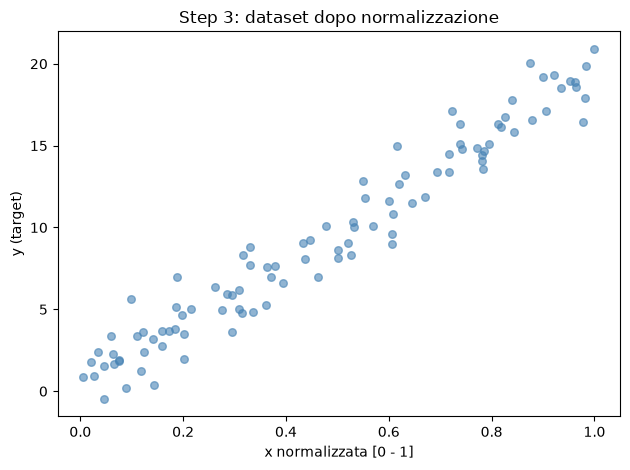

In [9]:
# ----------------------------------------------------------------
# Esercizio 1.1.1 - Simulare i Primi Step della Pipeline ML
#
# ----------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # fissa il seme: rende i risultati riproducibili ad ogni esecuzione

# STEP 1 - Raccolta dati (simulata)
n = 100
x = np.random.uniform(0, 10, n)
rumore = np.random.normal(0, 1.5, n)
y = 2 * x + rumore

# STEP 2 - EDA: statistiche descrittive di base
print("EDA - feature x:  media={:.2f}  min={:.2f}  max={:.2f}".format(x.mean(), x.min(), x.max()))
print("EDA - target  y:  media={:.2f}  min={:.2f}  max={:.2f}".format(y.mean(), y.min(), y.max()))

#STEP 3 Normalizzazione
x_norm = x / x.max()

# Verifica che la normalizzazione abbia funzionato
print("Dopo normalizzazione: x_norm in [{:.2f}, {:.2f}]".format(
    x_norm.min(), x_norm.max()))

# Grafico: scatter plot della feature normalizzata vs target
plt.figure()
plt.scatter(x_norm, y, alpha=0.6, color="steelblue", s=30)
plt.xlabel("x normalizzata [0 - 1]")
plt.ylabel("y (target)")
plt.title("Step 3: dataset dopo normalizzazione")
plt.tight_layout()
plt.show()





### Esercizio 1.1.2 - ML vs Programmazione Tradizionale

---

**Il cambio di paradigma:**

```
  PROGRAMMAZIONE TRADIZIONALE          MACHINE LEARNING

  Dati  ---+                           Dati  ---+
            |---> [ REGOLE ]               |    |
  Regole ---+     manuali   ---> Output   |    +--> [ MODELLO ] ---> Output
  (scritte a                         Esempi---+    (apprende le
   mano)                             etichettati    regole dai dati)
```

**Scenario:** rilevatore di transazioni bancarie sospette

**Dati a disposizione:**

| id | importo (euro) | nazione |
|----|----------------|---------|
| 1  | 200            | IT      |
| 2  | 6000           | DE      |
| 3  | 4500           | IT      |
| 4  | 8000           | FR      |
| 5  | 100            | US      |

**Versione A - Rule-based (programmazione tradizionale):**
```
    se importo > 5000 E nazione != "IT"  -->  sospetta
```

**Versione B - Score-based (approccio ML-like):**
```
    score = 0.6 * (importo / 10000) + 0.4 * (nazione != "IT")
    se score > 0.5                       -->  sospetta
```

I pesi 0.6 e 0.4 simulano cio che un modello ML avrebbe APPRESO dai dati
storici etichettati. In un modello reale non li scriveresti a mano.

**Cosa fare:**
1. Crea il DataFrame con i dati della tabella
2. Implementa le due funzioni `rule_based` e `score_based`
3. Applica entrambe a ogni riga e aggiungi le colonne al DataFrame
4. Stampa il risultato e individua le differenze tra i due approcci


In [ ]:
# ----------------------------------------------------------------
# Esercizio 1.1.2 - ML vs Programmazione Tradizionale
#
# ----------------------------------------------------------------


import pandas as pd

transazioni = pd.DataFrame({
    "id":       [1,    2,    3,   4,    5],
    "importo":  [200,  6000, 4500,8000, 100],
    "nazione":  ["IT", "DE", "IT", "FR", "US"]
})

# 1. RULE-BASED
def rule_based(importo, nazione):
    return importo > 5000 and nazione != "IT"

#2 SCORE-BASED
def score_based(importo, nazione):
    score = (importo / 10000) * 0.6 + (nazione != "IT") * 0.4
    sospetto = score > 0.5
    return round(score, 2), sospetto

transazioni["rule"] = transazioni.apply(
    lambda r: rule_based(r["importo"], r["nazione"]), axis=1
)

transazioni[["score", "score_sospetto"]] = transazioni.apply(
    lambda r: pd.Series(score_based(r["importo"], r["nazione"])), axis = 1
)

print(transazioni.to_string(index=False))
print()
print("Differenza chiave: transazione 5 (100 euro, USA)")
print("  rule_based   -> non sospetta (importo troppo basso)")
print("  score_based  -> sospetta (nazione estera pesa 0.4, basta a superare 0.5)")

 id  importo nazione  rule  score  score_sospetto
  1      200      IT False   0.01           False
  2     6000      DE  True   0.76            True
  3     4500      IT False   0.27           False
  4     8000      FR  True   0.88            True
  5      100      US False   0.41           False

Differenza chiave: transazione 5 (100 euro, USA)
  rule_based   -> non sospetta (importo troppo basso)
  score_based  -> sospetta (nazione estera pesa 0.4, basta a superare 0.5)


---
## Unita 1.2 - Dati, Modelli e Apprendimento

Un modello ML e una funzione parametrica f(x; theta) che trasforma
le feature in una predizione. Addestrarlo significa trovare i parametri
theta ottimali minimizzando l'errore sulle osservazioni disponibili.


### Esercizio 1.2.1 - Costruire e Esplorare un Dataset

---

**Notazione formale:**

```
  Dataset: D = { (x_i, y_i) }  per i = 1, ..., n

  x_i in R^d  = vettore delle feature dell'i-esima osservazione
  y_i         = target dell'i-esima osservazione
  n           = numero di osservazioni (righe)
  d           = numero di feature (colonne)
```

**Dati da generare:** dataset di 50 appartamenti

```
  Colonna     Tipo              Range
  --------    --------          --------
  mq          feature intera    [30, 150]
  piano       feature intera    [0, 10]
  zona        feature categ.    {A, B, C}
  prezzo      TARGET            calcolato
```

**Formula del target:**

```
    prezzo_i = 2000 * mq_i + 500 * piano_i + bonus_zona_i + epsilon_i

    dove  bonus_zona = 20000 se zona=A
                     = 10000 se zona=B
                     = 0     se zona=C
    e     epsilon ~ N(0, 5000)   (variabilita di mercato)
```

**Cosa fare:**
1. Genera le tre feature con `np.random.randint` e `np.random.choice`
2. Applica la formula del prezzo usando un dizionario per il bonus di zona
3. Crea il DataFrame pandas e mostra: `.head()`, `.describe()`, `.value_counts()` per zona


In [11]:
# ----------------------------------------------------------------
# Esercizio 1.2.1 - Costruire e Esplorare un Dataset
#
# ----------------------------------------------------------------

# TODO 1: Genera le tre feature con `np.random.randint` e `np.random.choice`
# TODO 2: Applica la formula del prezzo usando un dizionario per il bonus di zona
# TODO 3: Crea il DataFrame pandas e mostra: `.head()`, `.describe()`, `.value_counts()` per zona

import numpy as np

np.random.seed(0) #per lasciare i numeri uguali ad ogni run
n = 50 #numero di case

mq = np.random.randint(30, 151, n) #generami 50 numeri int casuali tra 30 e 150 (151 non incluso)
piano = np.random.randint(0, 11, n) #stessa cosa

zona = np.random.choice(["A", "B", "C"], n) # np.random.choice

# Bonus di zona: dizionario che mappa la categoria al valore numerico
zona_map = {"A": 20000, "B": 10000, "C": 0} # è un dizionario che stabilisce il listino prezzi dei bonus
zona_bonus = np.array([zona_map[z] for z in zona])

# Rumore gaussiano: simula la variabilita naturale del mercato immobiliare
rumore = np.random.normal(0, 5000, n)

# Target: combinazione lineare delle feature piu il rumore
prezzo = 2000 * mq + 500 * piano + zona_bonus + rumore

# Costruzione del DataFrame pandas
df = pd.DataFrame({
    "mq":     mq,
    "piano":  piano,
    "zona":   zona,
    "prezzo": prezzo.astype(int)
})

print(df.head())
print()

print(df.describe().round(0)) # calcola in automatico la media, il minimo e il massimo di mq, piani e prezzi
print()

print(df["zona"].value_counts()) #conta quante case sono capitate in zona A, quante in B e quante in C




    mq  piano zona  prezzo
0   74      9    B  159245
1   77      9    B  161006
2  147      0    B  297846
3   94     10    A  213970
4   97      4    B  201008

          mq  piano    prezzo
count   50.0   50.0      50.0
mean    93.0    5.0  196227.0
std     32.0    3.0   63552.0
min     39.0    0.0   72607.0
25%     68.0    3.0  151662.0
50%     96.0    4.0  209816.0
75%    117.0    8.0  239988.0
max    147.0   10.0  305138.0

zona
C    21
B    16
A    13
Name: count, dtype: int64


### Esercizio 1.2.2 - Spazio delle Ipotesi: Lineare vs Quadratico

---

**Definizione:**

Lo spazio delle ipotesi H e l'insieme di tutte le funzioni che un algoritmo
puo imparare. La scelta dell'algoritmo (o del grado del polinomio) stabilisce
quali relazioni il modello e CAPACE di rappresentare.

```
  Grado 1  ->  H = { f(x) = a*x + b }          solo rette
  Grado 2  ->  H = { f(x) = a*x^2 + b*x + c }  parabole e rette
  Grado k  ->  polinomi fino al grado k          sempre piu flessibili
```

**Dati sintetici** generati da una parabola con rumore:

```
    y = 0.5 * x^2 - x + 2 + epsilon       epsilon ~ N(0, 0.5)
    (relazione vera: parabola)             (rumore)
```

**Cosa succede con modelli di grado diverso:**

```
  y
  |      * *                   GRADO 1 (lineare):
  |    *     *    <- dati      non riesce a seguire la curvatura
  |   *         *              -> UNDERFITTING (bias elevato)
  |  *            *
  |  *                         GRADO 2 (quadratico):
  +--+---------+----> x        cattura la vera relazione
                               -> FITTING CORRETTO
```

**Formula del training MSE** (errore sui dati usati per il fit):

```
    MSE_train = (1/n) * somma( (y_pred_i - y_i)^2 )
```

**Cosa fare:**
1. Genera i dati con `np.random.seed(7)` e la formula sopra
2. Fitta grado 1 e grado 2 con `np.polyfit(x, y, deg=...)`
3. Calcola il training MSE per entrambi con `np.polyval`
4. Traccia entrambe le curve sullo stesso grafico e confronta


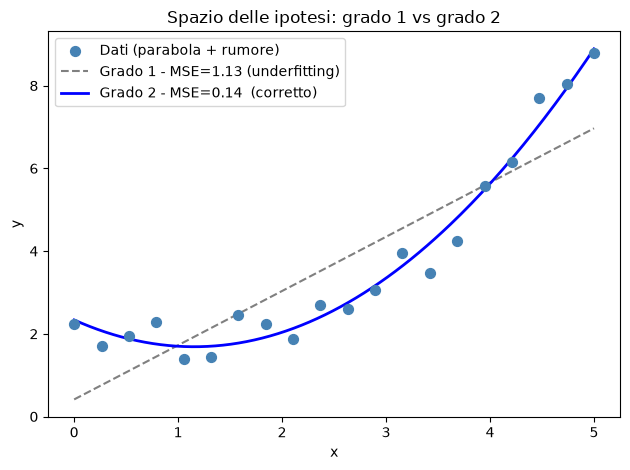

In [13]:
# ----------------------------------------------------------------
# Esercizio 1.2.3 - Spazio delle Ipotesi: Lineare vs Quadratico
#
# ----------------------------------------------------------------

np.random.seed(42)
x = np.linspace(0, 5, 20)  # questo crea la nostra feature
y = 0.5 * x **2 - x + 2 + np.random.normal(0, 0.5, 20)  # questo crea il nostro target che è una parabola con aggiunta di un rumore gaussiano per simulare le imperfezioni

# np.polyfit(x, y, deg): trova i coefficienti del polinomio di grado 'deg'
# che minimizza la somma degli errori quadratici (metodo OLS)
# Grado 1: restituisce [m, b]     ->  retta y = m*x + b
# Grado 2: restituisce [a, b, c]  ->  parabola y = a*x^2 + b*x + c
coef_lin = np.polyfit(x, y, deg=1)
coef_quad = np.polyfit(x, y, deg=2)

# Calcolo dell'Errore (Loss Function)
# np.polyval(coef, x_new): valuta il polinomio con quei coefficienti su nuovi punti
# Usiamo prima sui dati di training per calcolare il training MSE

mse_lin = np.mean((np.polyval(coef_lin, x) - y) ** 2 )
mse_quad = np.mean((np.polyval(coef_quad, x) - y) ** 2 )

# Creazione del Grafico (Visualizzazione del Modello)
#Crea una griglia molto più fitta (200 punti invece di 20) tra 0 e 5. 
# Serve unicamente a disegnare le linee del modello in modo fluido e continuo, 
# anziché vederle "a segmenti spezzati".
x_plot = np.linspace(0, 5, 200)


plt.figure()
#plt.scatter(...): Disegna i 20 punti reali originali come pallini blu (colore steelblue)
plt.scatter(x, y, color="steelblue", s=50, zorder=5, label="Dati (parabola + rumore)")

#Traccia una linea tratteggiata grigia (--) che mostra l'ipotesi lineare (la retta). 
# Nel grafico apparirà evidente che la retta taglia i dati in modo rozzo, 
# lasciando molti punti distanti: questa è la rappresentazione visiva dell'underfitting.
plt.plot(x_plot, np.polyval(coef_lin, x_plot),
        color="grey", linestyle="--",
        label="Grado 1 - MSE={:.2f} (underfitting)".format(mse_lin))

#Traccia una linea continua rossa spessa (linewidth=2) che mostra la parabola. 
# Questa curva seguirà perfettamente l'andamento ad arco dei punti, 
# dimostrando un fitting corretto.
plt.plot(x_plot, np.polyval(coef_quad, x_plot),
        color="blue", linewidth=2,
        label="Grado 2 - MSE={:.2f}  (corretto)".format(mse_quad))

#Questi comandi rifiniscono il grafico aggiungendo i nomi degli assi, 
# il titolo, la legenda con i valori di MSE calcolati e infine mostrano 
# la finestra grafica a schermo
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spazio delle ipotesi: grado 1 vs grado 2")
plt.legend()
plt.tight_layout()
plt.show()

---
## Unita 1.3 - Errore, Loss Function e Rischio Empirico

La loss function quantifica quanto e sbagliata una predizione.
Il training minimizza la media delle loss su tutti gli esempi
(Empirical Risk Minimization, ERM).


### Esercizio 1.3.1 - Confronto tra Loss Functions: MSE vs MAE

---

**Formule:**

```
  MSE (L2):  (1/n) * somma( (y_pred_i - y_real_i)^2 )   <- eleva al quadrato
  MAE (L1):  (1/n) * somma( |y_pred_i - y_real_i| )     <- valore assoluto
```

**Differenza chiave - comportamento con gli errori:**

```
  errore = 1  ->  MSE aggiunge  1,  MAE aggiunge  1
  errore = 2  ->  MSE aggiunge  4,  MAE aggiunge  2
  errore = 5  ->  MSE aggiunge 25,  MAE aggiunge  5
  errore = 10 ->  MSE aggiunge 100, MAE aggiunge 10
```

MSE penalizza esponenzialmente gli errori grandi: un singolo outlier
puo dominare il valore totale della loss e distorcere il training.

**Visualizzazione:**

```
  Loss
   |       /  <- MSE (parabola)
   |      /
   |    /
   |   / -- <- MAE (rette)
   |  /
   | /
   |/
   +--------> errore
   0
```

**Dati per questo esercizio:**

```
  y_real = [10, 20, 30, 40,  50]
  y_pred = [12, 18, 35, 38,  55]
```

**Cosa fare:**
1. Calcola MSE e MAE sul dataset originale
2. Sostituisci `y_real[4] = 200` (outlier) e ricalcola entrambe le metriche
3. Calcola di quante volte e aumentato ciascuna metrica
4. Conclude: quale e piu robusta agli outlier?


Senza outlier:  MSE=12.40     MAE=3.20
Con outlier:    MSE=4212.40   MAE=31.20
Aumento:        MSE x340      MAE x10


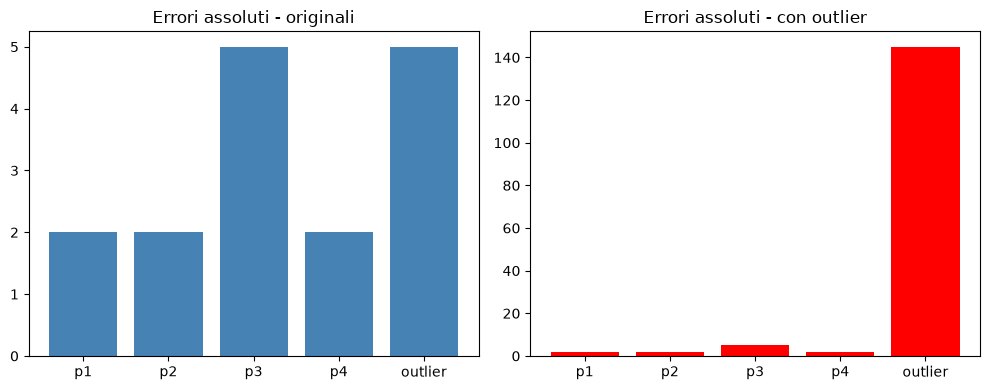

In [17]:
# ----------------------------------------------------------------
# Esercizio 1.3.1 - Confronto tra Loss Functions: MSE vs MAE
#
# ----------------------------------------------------------------
import numpy as np

y_real = np.array([10, 20, 30, 40, 50], dtype=float) #Sono i valori veri (target) di 5 campioni.
y_pred = np.array([12, 18, 35, 38, 55], dtype=float) #Sono le predizioni fatte dal nostro modello su quegli stessi 5 campioni.

#Calcolo delle metriche sui dati originali (Senza Outlier)
# MSE: eleva ogni errore al quadrato, poi fa la media
mse_orig = np.mean((y_pred - y_real) ** 2)

# MAE: prende il valore assoluto dell'errore, poi fa la media
mae_orig = np.mean(np.abs(y_pred - y_real)) # nb.abs fa il valore assoluto della differenza del predetto e reale e poi si fa la media

# Inserimento di un outlier: l'ultimo valore reale diventa 200
# Il modello continua a predire 55, ma il target reale e lontanissimo
y_real_out = y_real.copy() # copia per non modificare l'originale
y_real_out[4] = 200

# Ricalcolo delle metriche con l'Outlier
mse_out = np.mean((y_pred - y_real_out) ** 2)
mae_out = np.mean(np.abs(y_pred - y_real_out))

# Stampe e Risultati numerici
print("Senza outlier:  MSE={:.2f}     MAE={:.2f}".format(mse_orig, mae_orig))
print("Con outlier:    MSE={:.2f}   MAE={:.2f}".format(mse_out, mae_out))
print("Aumento:        MSE x{:.0f}      MAE x{:.0f}".format(mse_out/mse_orig, mae_out/mae_orig))
#La riga dell'Aumento ti mostrerà che mentre il MAE è aumentato di circa 10 volte, 
# l'MSE è aumentato di oltre 340 volte! Questo dimostra matematicamente 
# l'estrema sensibilità dell'MSE agli outlier.

# GENERAZIONE GRAFICI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
etichette = ["p1", "p2", "p3", "p4", "outlier"]
err_orig = np.abs(y_pred - y_real)
err_out = np.abs(y_pred - y_real_out)

ax1.bar(etichette, err_orig, color="steelblue")
ax1.set_title("Errori assoluti - originali")

ax2.bar(etichette, err_out, color="red")
ax2.set_title("Errori assoluti - con outlier")
plt.tight_layout()
plt.show()

### Esercizio 1.3.2 - Visualizzare Overfitting e Underfitting

---

**Definizioni:**

```
  UNDERFITTING (alto bias):
  - Il modello e troppo semplice per catturare il pattern
  - Errore alto su training E su test

  FITTING CORRETTO:
  - Il modello cattura la struttura reale senza memorizzare il rumore
  - Errore basso e simile su training e su test

  OVERFITTING (alta varianza):
  - Il modello memorizza anche il rumore del training
  - Errore molto basso su training, ma la curva diventa poco realistica
```

**Schema visivo:**

```
  y                 y                  y
  |  *   *          |   *              |  *   *
  |*   *   *        | *   *   *        |*   *   *
  |          *      |*        *  *     |          *
  |  retta   *      | parabola         | curva instabile
  +----------->x    +----------->x     +---------->x
  underfitting      fitting OK         overfitting
  (grado 1)         (grado 2)          (grado 5)
```

**Dati:** `y = x^2 + rumore`, con `x` compreso tra -3 e 3

**Cosa fare:**
1. Genera 20 punti con `np.random.seed(3)` e la formula sopra
2. Fitta tre polinomi di grado 1, 2 e 5 con `np.polyfit`
3. Calcola il training MSE per ciascun grado
4. Traccia i tre modelli sullo stesso grafico insieme ai dati
5. Commenta: quale grado generalizza meglio, secondo te, su dati nuovi?


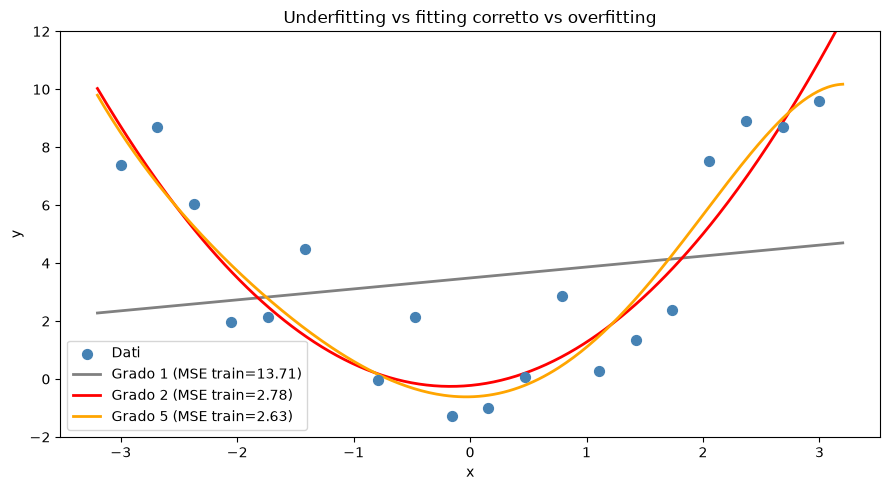

In [19]:
# ----------------------------------------------------------------
# Esercizio 1.3.3 - Visualizzare Overfitting e Underfitting
#
# ----------------------------------------------------------------

np.random.seed(123)
x_train = np.linspace(-3, 3, 20) #Genera 20 punti equispaziati tra -3 e 3. Questa è la nostra coordinata x
y_train = x_train ** 2 + np.random.normal(0, 1.5, 20) # Crea la coordinata y con la cordinata di sopra

# Tre gradi di complessita crescente
# grigio = troppo semplice, rosso = corretto, arancione = troppo complesso
gradi = [1,      2,     5]
colori =["gray", "red", "orange"]

x_plot = np.linspace(-3.2, 3.2, 300) 

plt.figure(figsize=(9, 5))
plt.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, label="Dati")

# Qui il codice usa un ciclo for per calcolare e disegnare i 3 modelli uno dopo l'altro:
for grado, colore in zip(gradi, colori):
    coef = np.polyfit(x_train, y_train, deg=grado)

    # Training MSE: errore sugli stessi 20 punti usati per il fit
    mse = np.mean((np.polyval(coef, x_train) - y_train)**2)

    curva = np.polyval(coef, x_plot)
    plt.plot(x_plot, curva, color=colore, linewidth=2,
             label="Grado {} (MSE train={:.2f})".format(grado, mse))


# Rifinitura del Grafico
plt.ylim(-2, 12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Underfitting vs fitting corretto vs overfitting")
plt.legend()
plt.tight_layout()
plt.show()



---
## Unita 1.4 - Valutazione dei Modelli

In questa unita impariamo a misurare quanto un modello e buono, con metriche
diverse per regressione e classificazione, e a stimarne le prestazioni in modo
affidabile con la K-Fold Cross Validation.


### Esercizio 1.4.1 - Metriche di Valutazione per la Regressione

---

**Metriche per la regressione:**

```
  MSE   = (1/n) * somma( (y_pred_i - y_i)^2 )        unita: [target]^2
  RMSE  = radice(MSE)                                  unita: [target]
  MAE   = (1/n) * somma( |y_pred_i - y_i| )           unita: [target]
  R^2   = 1 - MSE / Varianza(y)                        senza unita

  R^2 = 1.0  -> predizione perfetta
  R^2 = 0.0  -> equivalente a predire sempre la media
```

**Dati:** un piccolo modello ha gia calcolato le sue previsioni su 8 case

```
y_reale = [150, 200, 180, 240, 300, 220, 260, 190]   # prezzo vero (migliaia di euro)
y_pred  = [145, 210, 175, 230, 290, 225, 250, 200]   # prezzo previsto dal modello
```

**Cosa fare:**
1. Calcola MSE, RMSE, MAE con le formule sopra (solo NumPy, senza sklearn)
2. Calcola R^2 usando la formula `1 - MSE / Varianza(y_reale)`
3. Confronta RMSE e MAE: sono simili o diversi? Perche?

**Concetto chiave:** RMSE e MAE sono nella stessa unita di misura del target
(migliaia di euro), quindi sono facili da comunicare. R^2 invece e un numero
puro tra 0 e 1 (di solito) che dice quanta variabilita il modello spiega.


In [20]:
# ----------------------------------------------------------------
# Esercizio 1.4.1 - Metriche di Valutazione per la Regressione
#
# ----------------------------------------------------------------

import numpy as np

# Trasformiamo le liste di numeri in array NumPy di tipo float
y_reale = np.array([150, 200, 180, 240, 300, 220, 260, 190], dtype=float)
y_pred = np.array([145, 210, 175, 230, 290, 225, 250, 200], dtype=float)

# 1. CALCOLO MSE
mse = np.mean((y_pred - y_reale) ** 2)

# 2. CALCOLO RMSE (radice di MSE)
rmse = np.sqrt(mse)

# 3. CALCOLO MAE
mae = np.mean(np.abs(y_pred - y_reale))

# 4. CALCOLO R^2
r2 = 1 - mse / np.var(y_reale)

# stampe a schermo formattate
print("MSE:  {:.2f}".format(mse))
print("RMSE: {:.2f} (migliaia di euro)".format(rmse))
print("MAE:  {:.2f} (migliaia di euro)".format(mae))
print("R^2:  {:.2f}".format(r2))




MSE:  71.88
RMSE: 8.48 (migliaia di euro)
MAE:  8.12 (migliaia di euro)
R^2:  0.96


### Esercizio 1.4.2 - K-Fold Cross Validation

---

**Perche la CV e meglio di un singolo split:**

```
  SINGOLO SPLIT:            la stima dipende da come vengono divisi i dati
  +--------+------+
  | Train  | Test |         un solo valore di errore -> poco affidabile
  +--------+------+

  K-FOLD CV (qui k=5):      ogni punto e usato sia per train che per test
  +---+---+---+---+---+
  |Tr |Tr |Tr |Tr |Val|     giro 1: fold 5 e il test
  |Tr |Tr |Tr |Val|Tr |     giro 2: fold 4 e il test
  | ...                     ...
  |Val|Tr |Tr |Tr |Tr |     giro 5: fold 1 e il test
  +---+---+---+---+---+

  Errore finale = media dei 5 errori  (piu stabile e affidabile)
```

**Dati:** 10 misurazioni di un sensore, da dividere in k = 5 fold

```
valori = [12, 15, 11, 14, 13, 50, 12, 13, 15, 11]   # nota: un valore anomalo (50)
```

**Modello semplicissimo usato in ogni fold:** predice sempre la media
calcolata sui restanti 4 fold di training (lo stesso modello baseline
dell'Esercizio 1.3.2, qui applicato dentro ogni singolo giro).

**Cosa fare:**
1. Dividi `valori` in 5 fold da 2 elementi ciascuno con `np.array_split`
2. Per ogni fold: calcola la media degli altri 4 fold (training) e usala
   come previsione; calcola l'MSE sul fold lasciato fuori (validation)
3. Calcola la media dei 5 MSE ottenuti: e la stima finale della CV

**Concetto chiave:** ogni punto del dataset viene usato sia per allenare
sia per validare (mai nello stesso giro): la stima finale e piu stabile
di quella ottenuta con un singolo split casuale.


In [22]:
# ----------------------------------------------------------------
# Esercizio 1.4.2 - K-Fold Cross Validation
#
# ----------------------------------------------------------------

#Fase 1: Preparazione e Divisione in Fold
valori = np.array([12, 15, 11, 14, 13, 50, 12, 13, 15, 11], dtype=float)
k = 5
fold = np.array_split(valori, k)

# Fase 2: Il Ciclo di Cross Validation
mse_per_fold = [] # Una lista vuota dove salveremo l'errore MSE di ognuno dei 5 giri

for i in range(k):
    validation = fold[i]
    training = np.concatenate([fold[j] for j in range(k) if j != i])

# Fase 3: Predizione e Calcolo dell'MSE del giro
previsione = np.mean(training)
mse = np.mean((previsione - validation) ** 2)
mse_per_fold.append(mse)

print("Fold {}: validation= {}, prevision={:.2f}, MSE={:.2f}".format(
    i + 1, validation, previsione, mse
))

# Fase 4: Calcolo del Risultato Finale
print()
print("MSE medio della Cross Validation: {:.2f}".format(np.mean(mse_per_fold)))

Fold 5: validation= [15. 11.], prevision=17.50, MSE=24.25

MSE medio della Cross Validation: 24.25


### Esercizio 1.4.3 - Matrice di Confusione e Metriche di Classificazione

---

**Matrice di Confusione (classificazione binaria):**

```
                 PREDETTO
                 Positivo   Negativo
  REALE Positivo    TP         FN
        Negativo    FP         TN

  TP = predetto positivo, era positivo (corretto)
  TN = predetto negativo, era negativo (corretto)
  FP = predetto positivo, era negativo (falso allarme)
  FN = predetto negativo, era positivo (caso mancato)
```

**Metriche derivate:**

```
  Accuracy  = (TP + TN) / (TP + TN + FP + FN)
  Precision = TP / (TP + FP)
  Recall    = TP / (TP + FN)
  F1        = 2 * (Precision * Recall) / (Precision + Recall)
```

**Dati:** un piccolo classificatore di spam ha gia dato le sue previsioni
su 10 email (1 = spam, 0 = non spam)

```
y_reale = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0]
y_pred  = [1, 0, 0, 1, 0, 1, 1, 0, 1, 0]
```

**Cosa fare:**
1. Conta TP, TN, FP, FN confrontando `y_reale` e `y_pred` con maschere booleane
2. Calcola Accuracy, Precision, Recall e F1 con le formule sopra
3. Individua quale email e un falso positivo e quale un falso negativo

**Concetto chiave:** non serve nessun modello vero e proprio per esercitarsi
con queste metriche: bastano le previsioni gia fatte, confrontate con la
verita. E cosi che si valuta QUALSIASI classificatore, indipendentemente
da come e stato costruito.


In [ ]:
# ----------------------------------------------------------------
# Esercizio 1.4.3 - Matrice di Confusione e Metriche di Classificazione
#
# ----------------------------------------------------------------

# TODO 1: Conta TP, TN, FP, FN confrontando `y_reale` e `y_pred` con maschere booleane
# TODO 2: Calcola Accuracy, Precision, Recall e F1 con le formule sopra
# TODO 3: Individua quale email e un falso positivo e quale un falso negativo


